# **Dlib ile Yüz Noktaları Algılama**

####** Bu derste şunları öğreneceğiz:**
1. Yüz Noktaları Algılamayı Uygulama


In [40]:
!python --version

Python 3.12.7


In [5]:
!cmake --version  # Burada hata alıyorsanız cmake yüklemeniz gereklidir. 
# https://cmake.org/download/ adresinden indirip yükleyiniz

In [17]:
#dlib yüklemek için
!pip install dlib

Defaulting to user installation because normal site-packages is not writeable


In [21]:
import cv2
import dlib
import numpy as np
from matplotlib import pyplot as plt

 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Yüz Noktasal Tespiti**
Kod, dlib kütüphanesini kullanarak bir resimdeki yüzü buluyor ve 68 adet yüz noktasını (yüz ana noktaları: göz, burun, ağız, çene vb.) işaretliyor.

Sonra bu noktaları resim üzerinde numaralandırıp görselleştiriyor.

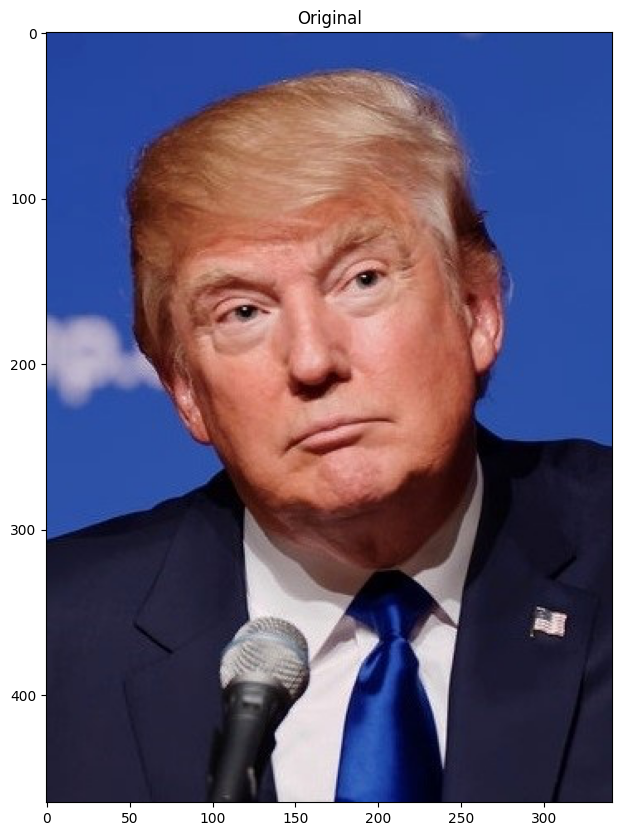

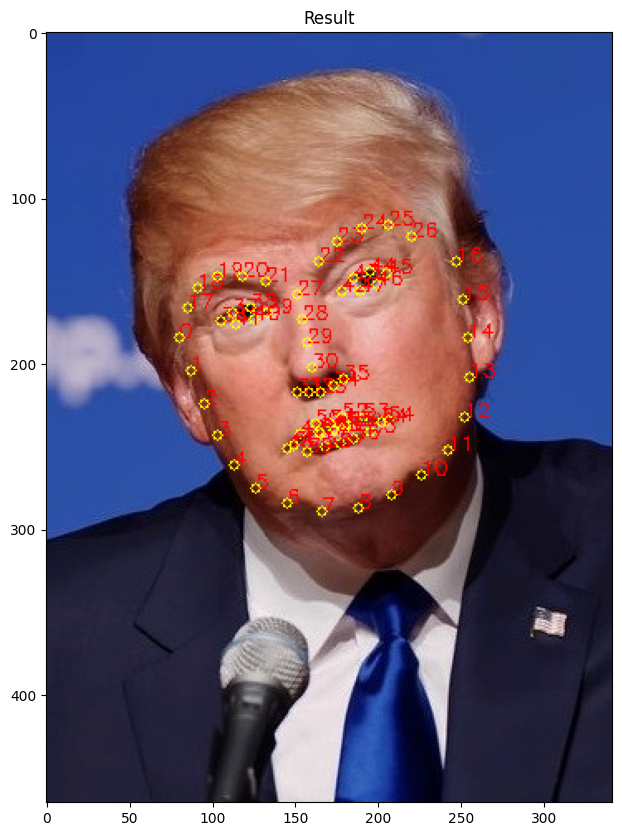

In [11]:
PREDICTOR_PATH = "../files/shape_predictor_68_face_landmarks.dat"
#Dlib’in önceden eğitilmiş bir landmark dedektör modeli. Bir yüz üzerinde 68 nokta işaretler.
predictor = dlib.shape_predictor(PREDICTOR_PATH) #Yüz tespiti yapar (frontal, yani önden görünen yüzlerde).
detector = dlib.get_frontal_face_detector() #Tespit edilen yüzün landmark noktalarını çıkarır.

class TooManyFaces(Exception):  #Eğer resimde birden fazla yüz bulunursa → TooManyFaces hatası verir
    pass

class NoFaces(Exception):  #Eğer hiç yüz bulunmazsa → NoFaces hatası nedeniyle 
    pass

def get_landmarks(im):   # Landmark çıkarma fonksiyonu
    rects = detector(im, 1)

    if len(rects) > 1:
        raise TooManyFaces
    if len(rects) == 0:
        raise NoFaces

    return np.matrix([[p.x, p.y] for p in predictor(im, rects[0]).parts()])

def annotate_landmarks(im, landmarks): # Landmark’ları görselleştirme
    im = im.copy()
    for idx, point in enumerate(landmarks):
        pos = (point[0, 0], point[0, 1])
        cv2.putText(im, str(idx), pos,
                    fontFace=cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,
                    fontScale=0.4,
                    
                    color=(0, 0, 255))
        cv2.circle(im, pos, 3, color=(0, 255, 255))
    return im

image = cv2.imread('../files/images/Trump.jpg')
imshow('Original', image)
landmarks = get_landmarks(image)
image_with_landmarks = annotate_landmarks(image, landmarks)
imshow('Result', image_with_landmarks)

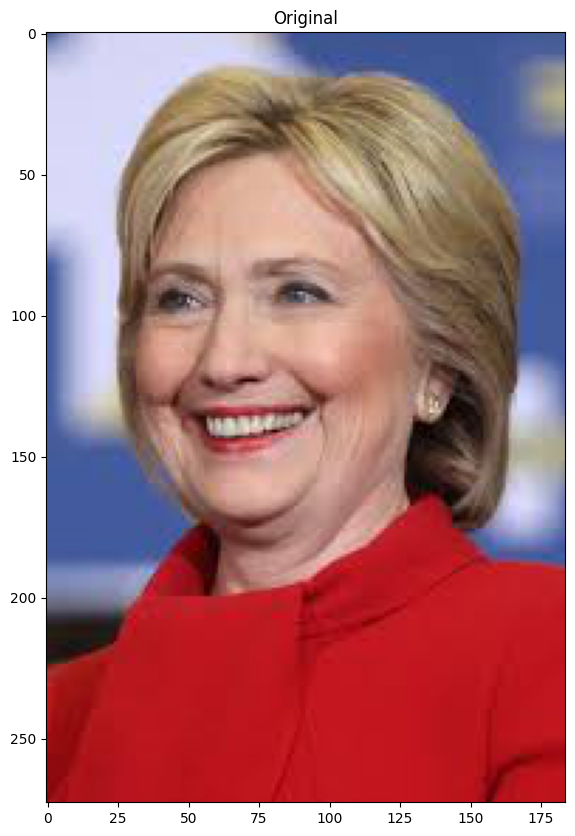

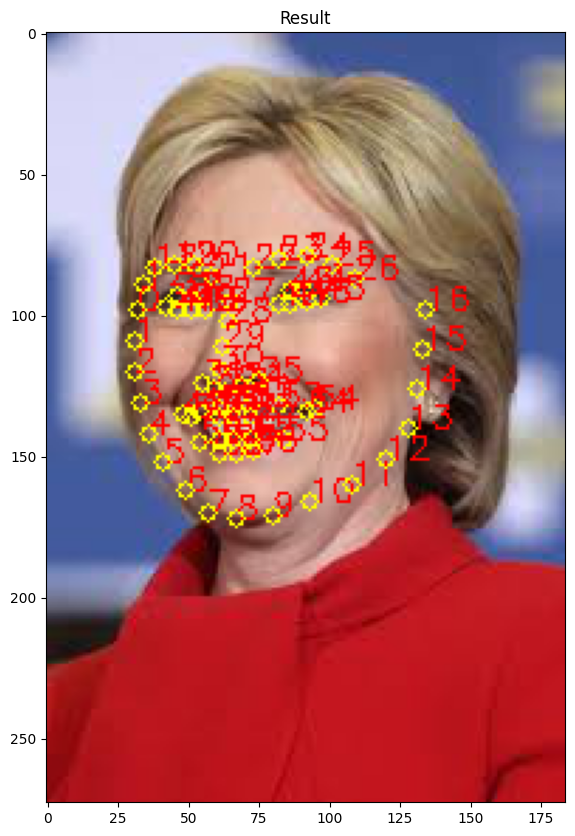

In [25]:
image = cv2.imread('../files/images/Hillary.jpg')
imshow('Original', image)
landmarks = get_landmarks(image)
image_with_landmarks = annotate_landmarks(image, landmarks)
imshow('Result', image_with_landmarks)